In [1]:

# CELL 1 — Inisialisasi, Preprocessing, & Feature Engineering
import tensorflow as tf
import numpy as np
import pandas as pd
import joblib
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print(f"TensorFlow Version: {tf.__version__}")

# 1. Load Dataset Asli (Sebelum di-scale)
df = pd.read_csv("cardio_processed (before scale).csv")

# 2. AI Engineer membuat beberapa kombinasi fitur sinyal kuat (Masukan Advisor)
# Landasan klinis:
#   ap_hi_x_age  → efek kumulatif hipertensi yang memburuk seiring usia
#   pp_x_age     → proxy kekakuan arteri (pulse pressure) berkorelasi usia
#   bmi_x_ap_hi  → risk multiplier: obesitas + tekanan darah tinggi bersamaan
df['ap_hi_x_age'] = df['ap_hi'] * df['age']
df['pp_x_age']    = df['pulse_pressure'] * df['age']
df['bmi_x_ap_hi'] = df['bmi'] * df['ap_hi']

# 3. Definisikan 24 Fitur Akhir Secara Ketat
FEATURE_NAMES = [
    'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'smoke', 'alco', 'active',
    'bmi', 'pulse_pressure', 'unhealthy_score',
    'cholesterol_1', 'cholesterol_2', 'cholesterol_3',
    'gluc_1', 'gluc_2', 'gluc_3',
    'bp_category_1', 'bp_category_2', 'bp_category_3',
    'ap_hi_x_age', 'pp_x_age', 'bmi_x_ap_hi'
]

X_raw  = df[FEATURE_NAMES]
y_data = df['cardio'].values.reshape(-1, 1)

print(f"Shape Input  : {X_raw.shape}")
print(f"Jumlah Fitur : {len(FEATURE_NAMES)} (12 base + 9 OHE + 3 interaksi)")

# =============================================================================
# 4. SPLIT DATA DULU — BARU SCALING
#
#   SEBELUMNYA (data leakage):
#    scaler.fit_transform(X_raw)      ← scaler melihat test set!
#    train_test_split(X_scaled, ...)
#
#    SEKARANG (benar):
#    train_test_split(X_raw, ...)      ← split data mentah dulu
#    scaler.fit_transform(X_train)     ← fit HANYA pada train
#    scaler.transform(X_val / X_test)  ← transform val & test tanpa fit
#
# Mengapa penting: jika scaler melihat distribusi test set saat fit,
# metrik evaluasi bisa 1-3% lebih optimis dari kenyataan (optimistic bias).
# =============================================================================

# Langkah 1: Split data RAW (sebelum scaling)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_raw, y_data, test_size=0.2, random_state=42, stratify=y_data
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# Langkah 2: Fit scaler HANYA pada X_train
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit + transform train
X_val   = scaler.transform(X_val)         # transform saja (tanpa fit)
X_test  = scaler.transform(X_test)        # transform saja (tanpa fit)

# Simpan scaler dengan joblib (direkomendasikan untuk sklearn objects)
joblib.dump(scaler, 'scaler_v7.pkl')
print("\n📦 Scaler disimpan: scaler_v7.pkl  (joblib, fit pada X_train saja)")

# 5. Bungkus ke tf.data.Dataset Pipeline
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(10000).batch(32).prefetch(tf.data.AUTOTUNE)
val_dataset   = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(32).prefetch(tf.data.AUTOTUNE)

#bagian ini menggunakan saran dari claude ai
print(f"\n Pembagian Data:")
print(f"   Train      : {len(X_train):,} sampel")
print(f"   Validation : {len(X_val):,} sampel")
print(f"   Test       : {len(X_test):,} sampel")
print(f"\n Verifikasi Anti-Leakage:")
print(f"   X_train mean = {X_train.mean():.4f}  (seharusnya ≈ 0.0)")
print(f"   X_train std  = {X_train.std():.4f}   (seharusnya ≈ 1.0)")
print(f"   X_test  mean = {X_test.mean():.4f}   (boleh ≠ 0 — tidak pernah dilihat scaler)")
print("\n Cell 1 selesai.")


TensorFlow Version: 2.20.0
Shape Input  : (68476, 24)
Jumlah Fitur : 24 (12 base + 9 OHE + 3 interaksi)

📦 Scaler disimpan: scaler_v7.pkl  (joblib, fit pada X_train saja)

 Pembagian Data:
   Train      : 43,824 sampel
   Validation : 10,956 sampel
   Test       : 13,696 sampel

 Verifikasi Anti-Leakage:
   X_train mean = -0.0000  (seharusnya ≈ 0.0)
   X_train std  = 1.0000   (seharusnya ≈ 1.0)
   X_test  mean = -0.0032   (boleh ≠ 0 — tidak pernah dilihat scaler)

 Cell 1 selesai.


In [2]:

# CELL 2 — Custom Components
# Wajib MQ2: 1 Layer + 1 Loss + 1 Metric + 1 Callback


#  1. Custom Layer: MedicalFeatureAttention
class MedicalFeatureAttention(layers.Layer):
    """
    Custom Layer — Bobot perhatian per-fitur yang dipelajari saat training.
    Softmax memastikan bobot terjumlah 1, sehingga interpretable sebagai
    'seberapa besar kontribusi fitur ini' secara relatif.
    """
    def __init__(self, **kwargs):
        super(MedicalFeatureAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.w = self.add_weight(
            name="attention_weight",
            shape=(input_shape[-1],),
            initializer="ones",
            trainable=True
        )
        super().build(input_shape)

    def call(self, inputs):
        attention_weights = tf.nn.softmax(self.w)
        return inputs * attention_weights

    def get_config(self):
        return super().get_config()


# 2. Custom Loss: ClinicalAsymmetricLoss
class ClinicalAsymmetricLoss(tf.keras.losses.Loss):
    """
    Custom Loss — Penalti asimetris: False Negative dihukum lebih berat.
    Landasan klinis: pasien berisiko yang terlewat (FN) jauh lebih berbahaya
    dibanding false alarm (FP) yang hanya membebani sumber daya.
    fn_weight=1.5 → kerugian deteksi pasien berisiko 1.5x lebih besar.
    """
    def __init__(self, fn_weight=1.5, **kwargs):
        super().__init__(**kwargs)
        self.fn_weight = fn_weight

    def call(self, y_true, y_pred):
        y_true   = tf.cast(y_true, tf.float32)
        epsilon  = tf.keras.backend.epsilon()
        y_pred   = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        loss_pos = -y_true * tf.math.log(y_pred) * self.fn_weight
        loss_neg = -(1.0 - y_true) * tf.math.log(1.0 - y_pred)
        return tf.reduce_mean(loss_pos + loss_neg)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'fn_weight': self.fn_weight})
        return cfg


#  3. Custom Metric: BinaryMAE
class BinaryMAE(tf.keras.metrics.Metric):
    """
    Custom Metric — Mean Absolute Error antara label biner prediksi vs aktual.
    Threshold disesuaikan dengan threshold evaluasi (0.40) agar konsisten.
    """
    def __init__(self, threshold=0.40, name='binary_mae', **kwargs):
        super(BinaryMAE, self).__init__(name=name, **kwargs)
        self.threshold = threshold
        self.total_mae = self.add_weight(name='total_mae', initializer='zeros')
        self.count     = self.add_weight(name='count',     initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true        = tf.cast(y_true, tf.float32)
        y_pred_binary = tf.cast(y_pred >= self.threshold, tf.float32)
        mae           = tf.reduce_mean(tf.abs(y_true - y_pred_binary))
        self.total_mae.assign_add(mae)
        self.count.assign_add(1.0)

    def result(self):
        return self.total_mae / (self.count + tf.keras.backend.epsilon())

    def reset_state(self):
        self.total_mae.assign(0.0)
        self.count.assign(0.0)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'threshold': self.threshold})
        return cfg


#  4. Custom Callback: TargetAchievedCallback
class TargetAchievedCallback(tf.keras.callbacks.Callback):
    """
    Custom Callback — Menghentikan pelatihan jika target val_accuracy DAN
    val_binary_mae tercapai bersamaan.
    Workaround: custom_model di-pass lewat __init__ karena GradientTape
    tidak me-attach self.model secara otomatis seperti model.fit().
    """
    def __init__(self, custom_model=None, target_acc=0.85, target_mae=0.02, **kwargs):
        super().__init__(**kwargs)
        self.custom_model = custom_model
        self.target_acc   = target_acc
        self.target_mae   = target_mae

    def on_epoch_end(self, epoch, logs=None):
        if logs is not None:
            acc = logs.get('val_accuracy', logs.get('accuracy', 0))
            mae = logs.get('val_binary_mae', logs.get('binary_mae', 1.0))
            if acc >= self.target_acc and mae <= self.target_mae:
                print(f"\n🎉 [TargetAchievedCallback] Target tercapai di epoch {epoch+1}!")
                print(f"   Val_Acc={acc:.4f} >= {self.target_acc}, Val_MAE={mae:.4f} <= {self.target_mae}")
                if self.custom_model:
                    self.custom_model.stop_training = True


print("Custom Layer    'MedicalFeatureAttention' siap.")
print("Custom Loss     'ClinicalAsymmetricLoss'  siap.  (fn_weight=1.5)")
print("Custom Metric   'BinaryMAE'               siap.  (threshold=0.40)")
print("Custom Callback 'TargetAchievedCallback'  siap.")


Custom Layer    'MedicalFeatureAttention' siap.
Custom Loss     'ClinicalAsymmetricLoss'  siap.  (fn_weight=1.5)
Custom Metric   'BinaryMAE'               siap.  (threshold=0.40)
Custom Callback 'TargetAchievedCallback'  siap.


In [3]:

# CELL 3 — Membangun Jaringan Functional API

from tensorflow.keras import layers, Model, regularizers

def build_integrated_network(input_dim=24):
    """
    CardioCare V7 Final — Arsitektur Functional API.

    Alur:
        Input (24) -> MedicalFeatureAttention
                   -> Dense(128, relu) + BatchNorm          [Blok 1]
                   -> Modified Parallel Residual             [Blok 2]
                      shortcut = Dense(64, relu)(d1)
                      x        = Dense(64, relu)(shortcut)
                      output   = Add([x, shortcut])
                      (kedua cabang melewati Dense — 'parallel path residual',
                       berbeda dari skip-connection murni; shortcut membawa
                       representasi menengah, bukan input asli)
                   -> Dropout(0.4)                           [Regularisasi]
                   -> Dense(1, sigmoid)                      [Output]
    """
    reg    = regularizers.l2(1e-4)
    inputs = layers.Input(shape=(input_dim,), name="input_layer")

    # Attention layer
    attention = MedicalFeatureAttention(name="attention_layer")(inputs)

    # Blok 1: Dense 128 + BatchNorm
    d1 = layers.Dense(128, activation='relu', kernel_regularizer=reg, name="dense_128")(attention)
    d1 = layers.BatchNormalization(name="bn_1")(d1)

    # Blok 2: Modified Parallel Residual Connection
    # shortcut membawa representasi d1 ke ruang 64-dim (bukan skip dari input asli)
    shortcut           = layers.Dense(64, activation='relu', kernel_regularizer=reg, name="shortcut")(d1)
    x                  = layers.Dense(64, activation='relu', kernel_regularizer=reg, name="dense_64")(shortcut)
    residual_connection = layers.Add(name="residual_add")([x, shortcut])
    x                  = layers.Activation('relu', name="residual_relu")(residual_connection)

    # Regularisasi
    x = layers.Dropout(0.4, name="dropout")(x)

    # Output
    outputs = layers.Dense(1, activation='sigmoid', name="prediction_layer")(x)

    return Model(inputs, outputs, name="CardioCare_Final_V7")


model = build_integrated_network(input_dim=len(FEATURE_NAMES))
model.summary()
print(f"\nInput dimension: {len(FEATURE_NAMES)} fitur")


Model: "CardioCare_Final_V7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, 24)        │         24 │ input_layer[0][0] │
│ (MedicalFeatureAtt… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_128 (Dense)   │ (None, 128)       │      3,200 │ attention_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 128)       │        512 │ dense_128[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shortcut (Dense)    │ (None, 64)        │      8,256 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_64 (Dense)    │ (None, 64)        │      4,160 │ shortcut[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_add (Add)  │ (None, 64)        │          0 │ dense_64[0][0],   │
│                     │                   │            │ shortcut[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_relu       │ (None, 64)        │          0 │ residual_add[0][… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ residual_relu[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction_layer    │ (None, 1)         │         65 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,217 (63.35 KB)

 Trainable params: 15,961 (62.35 KB)

 Non-trainable params: 256 (1.00 KB)


Input dimension: 24 fitur


In [4]:

# CELL 4 — Custom Training Loop dengan Early Stopping

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
loss_fn   = ClinicalAsymmetricLoss(fn_weight=1.5)

# Inisialisasi metrik (threshold seragam 0.40)
m_prec  = tf.keras.metrics.Precision()
m_rec   = tf.keras.metrics.Recall()
m_prauc = tf.keras.metrics.AUC(curve='PR')
m_acc   = tf.keras.metrics.BinaryAccuracy()
m_mae   = BinaryMAE(threshold=0.40)

# Callback side quest
target_callback = TargetAchievedCallback(custom_model=model, target_acc=0.85, target_mae=0.02)

@tf.function
def train_step(x_batch, y_batch):
    with tf.GradientTape() as tape:
        predictions = model(x_batch, training=True)
        loss_value  = loss_fn(y_batch, predictions)
    gradients = tape.gradient(loss_value, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    m_prec.update_state(y_batch, predictions)
    m_rec.update_state(y_batch, predictions)
    m_prauc.update_state(y_batch, predictions)
    m_acc.update_state(y_batch, predictions)
    m_mae.update_state(y_batch, predictions)
    return loss_value

@tf.function
def val_step(x_batch, y_batch):
    predictions = model(x_batch, training=False)
    v_loss = loss_fn(y_batch, predictions)
    m_prec.update_state(y_batch, predictions)
    m_rec.update_state(y_batch, predictions)
    m_prauc.update_state(y_batch, predictions)
    m_acc.update_state(y_batch, predictions)
    m_mae.update_state(y_batch, predictions)
    return v_loss

# History
training_history = {
    'loss': [], 'accuracy': [], 'recall': [], 'precision': [],
    'f1_score': [], 'pr_auc': [], 'binary_mae': [],
    'val_loss': [], 'val_accuracy': [], 'val_recall': [],
    'val_precision': [], 'val_f1_score': [], 'val_pr_auc': [], 'val_binary_mae': []
}

# =============================================================================
# Early Stopping Variables mengambil saran dari claude ai
# ─────────────────────────────────────────────────────────────────────────────
# PATIENCE  : jumlah epoch tanpa perbaikan sebelum berhenti
# MIN_DELTA : minimum perbaikan yang dianggap bermakna
#             (mencegah fluktuasi kecil 0.0001 dari mereset counter)
# RESTORE_BEST_WEIGHTS : kembalikan bobot ke epoch terbaik di akhir training
#             — berlaku baik saat patience habis MAUPUN epoch habis secara natural
# =============================================================================
EPOCHS               = 100
PATIENCE             = 15
MIN_DELTA            = 1e-4     # ← FIX: perbaikan kecil tidak mereset counter
RESTORE_BEST_WEIGHTS = True

best_val_loss    = float('inf')
best_weights     = None
best_epoch       = 0
patience_counter = 0

print("\n🚀 Memulai Pelatihan CardioCare V7 Final")
print(f"   Max Epochs   : {EPOCHS}")
print(f"   Patience     : {PATIENCE} epoch")
print(f"   Min Delta    : {MIN_DELTA}")
print(f"   Monitor      : val_loss")
print(f"   Restore Best : {RESTORE_BEST_WEIGHTS}")
print(f"   Loss Fn      : ClinicalAsymmetricLoss (fn_weight=1.5)")
print(f"   Threshold    : 0.40 (konsisten train & evaluasi)\n")

for epoch in range(EPOCHS):

    # ── PHASE 1: TRAINING ─────────────────────────────────────────────────
    train_losses = []
    for x_batch, y_batch in train_dataset:
        loss_value = train_step(x_batch, y_batch)
        train_losses.append(loss_value)

    t_prec = m_prec.result().numpy()
    t_rec  = m_rec.result().numpy()
    t_f1   = 2 * (t_prec * t_rec) / (t_prec + t_rec + 1e-7)

    training_history['loss'].append(float(np.mean(train_losses)))
    training_history['accuracy'].append(float(m_acc.result()))
    training_history['precision'].append(float(t_prec))
    training_history['recall'].append(float(t_rec))
    training_history['f1_score'].append(float(t_f1))
    training_history['pr_auc'].append(float(m_prauc.result()))
    training_history['binary_mae'].append(float(m_mae.result()))

    for m in [m_prec, m_rec, m_prauc, m_acc, m_mae]: m.reset_state()

    # ── PHASE 2: VALIDATION ───────────────────────────────────────────────
    val_losses = []
    for x_val_batch, y_val_batch in val_dataset:
        v_loss = val_step(x_val_batch, y_val_batch)
        val_losses.append(v_loss)

    v_prec           = m_prec.result().numpy()
    v_rec            = m_rec.result().numpy()
    v_f1             = 2 * (v_prec * v_rec) / (v_prec + v_rec + 1e-7)
    current_val_loss = float(np.mean(val_losses))

    training_history['val_loss'].append(current_val_loss)
    training_history['val_accuracy'].append(float(m_acc.result()))
    training_history['val_precision'].append(float(v_prec))
    training_history['val_recall'].append(float(v_rec))
    training_history['val_f1_score'].append(float(v_f1))
    training_history['val_pr_auc'].append(float(m_prauc.result()))
    training_history['val_binary_mae'].append(float(m_mae.result()))

    # ── PHASE 3: EARLY STOPPING CHECK ────────────────────────────────────
    # FIX: pakai MIN_DELTA agar fluktuasi kecil tidak dianggap perbaikan
    improved = current_val_loss < (best_val_loss - MIN_DELTA)

    if improved:
        best_val_loss    = current_val_loss
        best_epoch       = epoch + 1
        patience_counter = 0
        if RESTORE_BEST_WEIGHTS:
            best_weights = model.get_weights()
        marker = "   best"
    else:
        patience_counter += 1
        marker = f"  (no improve {patience_counter}/{PATIENCE})"

    print(
        f"Epoch {epoch+1:03d} | "
        f"Loss: {training_history['loss'][-1]:.4f}  "
        f"Val_Loss: {current_val_loss:.4f}{marker} | "
        f"Val_Acc: {training_history['val_accuracy'][-1]:.4f}  "
        f"Val_Recall: {v_rec:.4f}  "
        f"Val_F1: {v_f1:.4f}"
    )

    for m in [m_prec, m_rec, m_prauc, m_acc, m_mae]: m.reset_state()

    # Stop jika patience habis
    if patience_counter >= PATIENCE:
        print(f"\n  Early Stopping dipicu! Val_Loss tidak membaik selama {PATIENCE} epoch.")
        break

    # ── PHASE 4: CALLBACK SIDE QUEST ─────────────────────────────────────
    logs = {k: v[-1] for k, v in training_history.items()}
    target_callback.on_epoch_end(epoch, logs)
    if getattr(model, 'stop_training', False):
        break

# =============================================================================
# RESTORE BOBOT TERBAIK
# FIX dari revisi_7_fixed: restore dilakukan di luar loop sehingga
# berlaku baik saat patience habis MAUPUN saat epoch habis secara natural.
# =============================================================================
if RESTORE_BEST_WEIGHTS and best_weights is not None:
    model.set_weights(best_weights)
    print(f"\n Bobot dikembalikan ke epoch {best_epoch} (best val_loss: {best_val_loss:.4f})")

actual_epochs = len(training_history['loss'])
print(f"\n Training selesai.")
print(f"   Berjalan    : {actual_epochs} epoch dari maksimum {EPOCHS}")
print(f"   Best epoch  : {best_epoch}")
print(f"   Best val_loss: {best_val_loss:.4f}")



🚀 Memulai Pelatihan CardioCare V7 Final
   Max Epochs   : 100
   Patience     : 15 epoch
   Min Delta    : 0.0001
   Monitor      : val_loss
   Restore Best : True
   Loss Fn      : ClinicalAsymmetricLoss (fn_weight=1.5)
   Threshold    : 0.40 (konsisten train & evaluasi)

Epoch 001 | Loss: 0.6904  Val_Loss: 0.6764   best | Val_Acc: 0.7282  Val_Recall: 0.7006  Val_F1: 0.7184
Epoch 002 | Loss: 0.6757  Val_Loss: 0.6642   best | Val_Acc: 0.7191  Val_Recall: 0.7727  Val_F1: 0.7314
Epoch 003 | Loss: 0.6741  Val_Loss: 0.6634   best | Val_Acc: 0.7212  Val_Recall: 0.7567  Val_F1: 0.7287
Epoch 004 | Loss: 0.6713  Val_Loss: 0.6612   best | Val_Acc: 0.7245  Val_Recall: 0.7480  Val_F1: 0.7288
Epoch 005 | Loss: 0.6693  Val_Loss: 0.6613  (no improve 1/15) | Val_Acc: 0.7199  Val_Recall: 0.7672  Val_F1: 0.7305
Epoch 006 | Loss: 0.6692  Val_Loss: 0.6611  (no improve 2/15) | Val_Acc: 0.7214  Val_Recall: 0.7714  Val_F1: 0.7327
Epoch 007 | Loss: 0.6681  Val_Loss: 0.6602   best | Val_Acc: 0.7213  Val_Reca

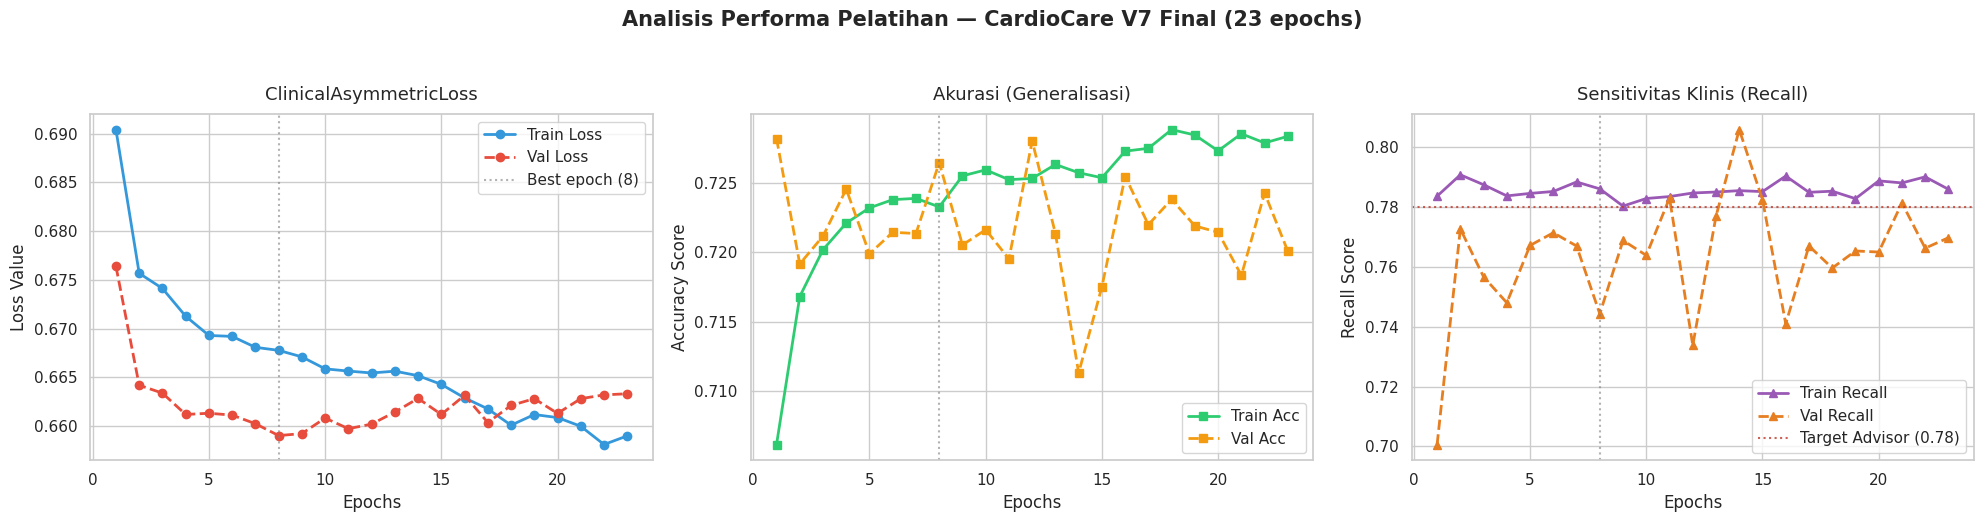

Plot disimpan: training_history_v7.png


In [5]:

# CELL 5 — Visualisasi Evaluasi Model (Train vs Validation)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

epochs_range = range(1, actual_epochs + 1)
hist         = training_history

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle(
    f'Analisis Performa Pelatihan — CardioCare V7 Final ({actual_epochs} epochs)',
    fontsize=15, fontweight='bold', y=1.04
)

# Plot 1: Loss
axes[0].plot(epochs_range, hist['loss'],     marker='o', color='#3498db', linewidth=2, label='Train Loss')
axes[0].plot(epochs_range, hist['val_loss'], marker='o', color='#e74c3c', linewidth=2, linestyle='--', label='Val Loss')
axes[0].axvline(x=best_epoch, color='gray', linestyle=':', alpha=0.6, label=f'Best epoch ({best_epoch})')
axes[0].set_title('ClinicalAsymmetricLoss', fontsize=13, pad=10)
axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('Loss Value')
axes[0].legend()

# Plot 2: Accuracy
axes[1].plot(epochs_range, hist['accuracy'],     marker='s', color='#2ecc71', linewidth=2, label='Train Acc')
axes[1].plot(epochs_range, hist['val_accuracy'], marker='s', color='#f39c12', linewidth=2, linestyle='--', label='Val Acc')
axes[1].axvline(x=best_epoch, color='gray', linestyle=':', alpha=0.6)
axes[1].set_title('Akurasi (Generalisasi)', fontsize=13, pad=10)
axes[1].set_xlabel('Epochs'); axes[1].set_ylabel('Accuracy Score')
axes[1].legend()

# Plot 3: Recall dengan garis target
axes[2].plot(epochs_range, hist['recall'],     marker='^', color='#9b59b6', linewidth=2, label='Train Recall')
axes[2].plot(epochs_range, hist['val_recall'], marker='^', color='#e67e22', linewidth=2, linestyle='--', label='Val Recall')
axes[2].axhline(y=0.78, color='#c0392b', linestyle=':', alpha=0.8, linewidth=1.5, label='Target Advisor (0.78)')
axes[2].axvline(x=best_epoch, color='gray', linestyle=':', alpha=0.6)
axes[2].set_title('Sensitivitas Klinis (Recall)', fontsize=13, pad=10)
axes[2].set_xlabel('Epochs'); axes[2].set_ylabel('Recall Score')
axes[2].legend()

plt.tight_layout()
plt.savefig('training_history_v7.png', dpi=120, bbox_inches='tight')
plt.show()
print("Plot disimpan: training_history_v7.png")
# ← model.save() dihapus dari sini, dipindah ke Cell 7 (satu tempat, bersih)


## Cell 6 — Laporan Klinis & Justifikasi Threshold

  CARDIOCARE FINAL CLINICAL EVALUATION (TEST SET)
  Decision Strategy : Maximizing Recall for Patient Safety
  Selected Threshold: 0.4
  Total Test Data   : 13,696 samples
  Scaling Method    : StandardScaler fit pada X_train saja (no leakage)
  Best Training Epoch: 8 / 23
-----------------------------------------------------------------
  [ANALISIS KLINIS]
  Dari 6,777 pasien berisiko jantung dalam data uji:
  - Berhasil Terdeteksi : 5,605 orang  (82.71%)
  - Terlewat (FN)       : 1,172 orang  <- kekurangan model
  PR-AUC                : 0.7801  (lebih robust untuk data imbalanced)

  [TABEL PERBANDINGAN STRATEGI THRESHOLD]
                         Recall (Sensitivitas) Precision F1-Score Akurasi Pasien Terlewat (FN)
Threshold 0.50 (Standar)                74.40%    71.66%   73.00%  72.77%                 1735
Threshold 0.40 (Medis)                  82.71%    65.66%   73.20%  70.04%                 1172

-----------------------------------------------------------------
  CLASSIFICATI

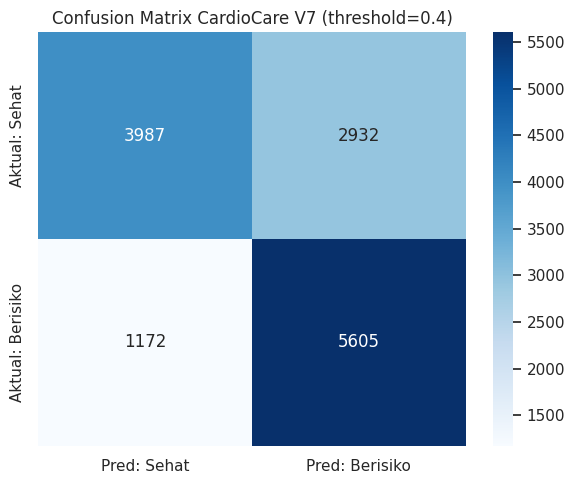

  JUSTIFIKASI THRESHOLD 0.40:
  Dibanding threshold standar 0.50, threshold 0.40 berhasil
  menyelamatkan 563 pasien tambahan dari risiko terlewat.
  Trade-off: akurasi turun namun Recall naik signifikan.
  Dalam konteks klinis, FN (pasien terlewat) jauh lebih berbahaya
  dibanding FP (false alarm yang bisa diklarifikasi dokter).


In [6]:

# CELL 6 — Laporan Medis Akhir & Justifikasi Threshold

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, recall_score, f1_score, precision_score,
    average_precision_score
)
import seaborn as sns

# 1. Prediksi probabilitas pada test set (test set = hold-out, belum pernah dilihat model)
y_pred_prob = model.predict(X_test, verbose=0)

def get_metrics(threshold):
    y_pred = (y_pred_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    return {
        'Recall (Sensitivitas)' : f"{recall_score(y_test, y_pred)*100:.2f}%",
        'Precision'             : f"{precision_score(y_test, y_pred)*100:.2f}%",
        'F1-Score'              : f"{f1_score(y_test, y_pred)*100:.2f}%",
        'Akurasi'               : f"{accuracy_score(y_test, y_pred)*100:.2f}%",
        'Pasien Terlewat (FN)'  : fn
    }

# 2. Tabel perbandingan threshold (diminta advisor)
comparison_data = {
    'Threshold 0.50 (Standar)': get_metrics(0.50),
    'Threshold 0.40 (Medis)'  : get_metrics(0.40),
}
df_compare = pd.DataFrame(comparison_data).T

# 3. Evaluasi final dengan threshold medis 0.40
THRESHOLD_FINAL = 0.40
y_final         = (y_pred_prob >= THRESHOLD_FINAL).astype(int)
tn, fp, fn, tp  = confusion_matrix(y_test, y_final).ravel()
pr_auc          = average_precision_score(y_test, y_pred_prob)

print("=" * 65)
print("  CARDIOCARE FINAL CLINICAL EVALUATION (TEST SET)")
print("=" * 65)
print(f"  Decision Strategy : Maximizing Recall for Patient Safety")
print(f"  Selected Threshold: {THRESHOLD_FINAL}")
print(f"  Total Test Data   : {len(y_test):,} samples")
print(f"  Scaling Method    : StandardScaler fit pada X_train saja (no leakage)")
print(f"  Best Training Epoch: {best_epoch} / {actual_epochs}")
print("-" * 65)
print(f"  [ANALISIS KLINIS]")
print(f"  Dari {tp+fn:,} pasien berisiko jantung dalam data uji:")
print(f"  - Berhasil Terdeteksi : {tp:,} orang  ({recall_score(y_test, y_final)*100:.2f}%)")
print(f"  - Terlewat (FN)       : {fn:,} orang  <- kekurangan model")
print(f"  PR-AUC                : {pr_auc:.4f}  (lebih robust untuk data imbalanced)")
print(f"\n  [TABEL PERBANDINGAN STRATEGI THRESHOLD]")
print(df_compare.to_string())
print("\n" + "-" * 65)
print("  CLASSIFICATION REPORT — Threshold 0.40 (Test Set)")
print("-" * 65)
print(classification_report(y_test, y_final, target_names=['Sehat', 'Berisiko Jantung']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Sehat', 'Pred: Berisiko'],
            yticklabels=['Aktual: Sehat', 'Aktual: Berisiko'], ax=ax)
ax.set_title(f'Confusion Matrix CardioCare V7 (threshold={THRESHOLD_FINAL})', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_v7.png', dpi=120)
plt.show()


# saya meminta saran dari claude ai untuk menambahkan justifikasi threshold 0.40 dibandingkan 0.50, dengan fokus pada pengurangan False Negatives (pasien terlewat) yang sangat krusial dalam konteks klinis.
fn_std = int(df_compare.loc['Threshold 0.50 (Standar)', 'Pasien Terlewat (FN)'])
print("=" * 65)
print(f"  JUSTIFIKASI THRESHOLD 0.40:")
print(f"  Dibanding threshold standar 0.50, threshold 0.40 berhasil")
print(f"  menyelamatkan {fn_std - fn:,} pasien tambahan dari risiko terlewat.")
print(f"  Trade-off: akurasi turun namun Recall naik signifikan.")
print(f"  Dalam konteks klinis, FN (pasien terlewat) jauh lebih berbahaya")
print(f"  dibanding FP (false alarm yang bisa diklarifikasi dokter).")
print("=" * 65)


In [7]:

# CELL 7 — Export Model Final & Simulasi Prediksi Pasien Baru


# 1. Ekspor model
MODEL_NAME = "cardiocare_model_v7.keras"
model.save(MODEL_NAME)
print(f" Model disimpan : {MODEL_NAME}")

# 2. Metadata lengkap
metadata = {
    'model_name'       : 'CardioCare V7 Final',
    'version'          : 'revisi_7_final',
    'threshold_medis'  : 0.40,
    'input_dim'        : len(FEATURE_NAMES),
    'feature_names'    : FEATURE_NAMES,
    'scaler_file'      : 'scaler_v7.pkl',
    'scaling_method'   : 'StandardScaler.fit(X_train) only — no data leakage',
    'best_epoch'       : best_epoch,
    'best_val_loss'    : round(best_val_loss, 6),
    'training_epochs'  : actual_epochs,
    'loss_function'    : 'ClinicalAsymmetricLoss (fn_weight=1.5)',
    'early_stopping'   : f'patience={PATIENCE}, min_delta={MIN_DELTA}, restore_best=True',
    'target_recall'    : '>78% (advisor target)',
}
joblib.dump(metadata, 'model_metadata.pkl')
print(f" Metadata disimpan: model_metadata.pkl")
print(f" Scaler disimpan  : scaler_v7.pkl  (joblib)")

# 3. Ringkasan artifact
print("\n Daftar File Output:")
print(f"   cardiocare_model_v7.keras — model terlatih")
print(f"   scaler_v7.pkl             — scaler (fit X_train saja)")
print(f"   model_metadata.pkl        — metadata & konfigurasi")
print(f"   training_history_v7.png   — grafik training")
print(f"   confusion_matrix_v7.png   — confusion matrix test set")

# 4. Simulasi prediksi pasien baru dengan bantuan claude ai untuk menunjukkan interpretasi hasil prediksi probabilitas dan diagnosis akhir berdasarkan threshold medis 0.40.
print("\n" + "="*55)
print("  SIMULASI PREDIKSI PASIEN BARU")
print("="*55)

sample_index = 10
sample_data  = X_test[sample_index].reshape(1, -1)
actual_label = int(y_test[sample_index])

probabilitas = float(model.predict(sample_data, verbose=0)[0][0])
diagnosis    = "BERISIKO" if probabilitas >= 0.40 else "SEHAT"
aktual_str   = "BERISIKO" if actual_label == 1 else "SEHAT"

print(f"  Pasien ID (Index)   : {sample_index}")
print(f"  Probabilitas Risiko : {probabilitas*100:.2f}%")
print(f"  Ambang Batas Medis  : 40.00%")
print(f"  HASIL DIAGNOSA AI   : {diagnosis}")
print(f"  Label Sebenarnya    : {aktual_str}")
print("-"*55)

if diagnosis == aktual_str:
    print("  Hasil AI Akurat.")
else:
    print("    AI memberikan peringatan dini (Screening Mode).")
print("="*55)


 Model disimpan : cardiocare_model_v7.keras
 Metadata disimpan: model_metadata.pkl
 Scaler disimpan  : scaler_v7.pkl  (joblib)

 Daftar File Output:
   cardiocare_model_v7.keras — model terlatih
   scaler_v7.pkl             — scaler (fit X_train saja)
   model_metadata.pkl        — metadata & konfigurasi
   training_history_v7.png   — grafik training
   confusion_matrix_v7.png   — confusion matrix test set

  SIMULASI PREDIKSI PASIEN BARU


/tmp/ipykernel_2184/1465309570.py:44: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual_label = int(y_test[sample_index])


  Pasien ID (Index)   : 10
  Probabilitas Risiko : 88.87%
  Ambang Batas Medis  : 40.00%
  HASIL DIAGNOSA AI   : BERISIKO
  Label Sebenarnya    : BERISIKO
-------------------------------------------------------
  Hasil AI Akurat.


In [8]:
# CELL 8 — Inference Function (Melengkapi MQ4)
# Letakkan cell ini SETELAH Cell 7 (Export Model)
# =============================================================================

# ── 1. Custom Objects Dict (wajib untuk load model) ──────────────────────────
# Tanpa ini, keras.models.load_model() akan error karena tidak mengenali
# MedicalFeatureAttention, ClinicalAsymmetricLoss, dan BinaryMAE.

CUSTOM_OBJECTS = {
    'MedicalFeatureAttention' : MedicalFeatureAttention,
    'ClinicalAsymmetricLoss'  : ClinicalAsymmetricLoss,
    'BinaryMAE'               : BinaryMAE,
}

# ── 2. Verifikasi Model Bisa Di-load Ulang ────────────────────────────────────
loaded_model = tf.keras.models.load_model(
    'cardiocare_model_v7.keras',
    custom_objects=CUSTOM_OBJECTS
)
print(f" Model berhasil di-load: input={loaded_model.input_shape}")


# ── 3. Fungsi Inference (Input Raw dari FS) ───────────────────────────────────
def predict_cardio(raw_input: dict) -> dict:
    """
    Prediksi risiko penyakit jantung dari input mentah.

    Parameter (11 field dari FS):
        age         (int)   : usia dalam tahun
        gender      (int)   : 1 = perempuan, 2 = laki-laki
        height      (int)   : tinggi badan dalam cm
        weight      (float) : berat badan dalam kg
        ap_hi       (int)   : tekanan darah sistolik (mmHg)
        ap_lo       (int)   : tekanan darah diastolik (mmHg)
        cholesterol (int)   : 1=normal, 2=di atas normal, 3=jauh di atas normal
        gluc        (int)   : 1=normal, 2=di atas normal, 3=jauh di atas normal
        smoke       (int)   : 0=tidak merokok, 1=merokok
        alco        (int)   : 0=tidak minum alkohol, 1=minum
        active      (int)   : 0=tidak aktif, 1=aktif fisik

    Returns:
        dict: {
            "risk"          : 0 atau 1,
            "probability"   : float (0.0 - 1.0),
            "threshold_used": 0.40,
            "label"         : "Berisiko" atau "Tidak Berisiko"
        }
    """
    # ── Validasi input ─────────────────────────────────────────────────────
    required = ["age","gender","height","weight","ap_hi","ap_lo",
                "cholesterol","gluc","smoke","alco","active"]
    missing = [k for k in required if k not in raw_input]
    if missing:
        raise ValueError(f"Field wajib tidak ada: {missing}")
    if raw_input["cholesterol"] not in [1, 2, 3]:
        raise ValueError(f"cholesterol harus 1/2/3, dapat: {raw_input['cholesterol']}")
    if raw_input["gluc"] not in [1, 2, 3]:
        raise ValueError(f"gluc harus 1/2/3, dapat: {raw_input['gluc']}")
    if raw_input["ap_hi"] <= raw_input["ap_lo"]:
        raise ValueError(f"ap_hi ({raw_input['ap_hi']}) harus lebih besar dari ap_lo ({raw_input['ap_lo']})")

    # ── Feature engineering (direplikasi dari Cell 1) ─────────────────────
    age    = float(raw_input["age"])
    height = float(raw_input["height"])
    weight = float(raw_input["weight"])
    ap_hi  = float(raw_input["ap_hi"])
    ap_lo  = float(raw_input["ap_lo"])

    bmi             = weight / ((height / 100) ** 2)
    pulse_pressure  = ap_hi - ap_lo
    unhealthy_score = (1 if raw_input["smoke"]  else 0) + \
                      (1 if raw_input["alco"]   else 0) + \
                      (0 if raw_input["active"] else 1)

    # OHE cholesterol
    chol    = int(raw_input["cholesterol"])
    chol_1  = int(chol == 1)
    chol_2  = int(chol == 2)
    chol_3  = int(chol == 3)

    # OHE gluc
    gl      = int(raw_input["gluc"])
    gluc_1  = int(gl == 1)
    gluc_2  = int(gl == 2)
    gluc_3  = int(gl == 3)

    # OHE bp_category (replikasi logika dari DS)
    if ap_hi < 120 and ap_lo < 80:
        bp_cat = 1   # Normal
    elif ap_hi < 130 and ap_lo < 80:
        bp_cat = 2   # Elevated
    else:
        bp_cat = 3   # High
    bp_1 = int(bp_cat == 1)
    bp_2 = int(bp_cat == 2)
    bp_3 = int(bp_cat == 3)

    # 3 Fitur interaksi (wajib sama persis dengan Cell 1)
    ap_hi_x_age  = ap_hi * age
    pp_x_age     = pulse_pressure * age
    bmi_x_ap_hi  = bmi * ap_hi

    # ── Susun baris fitur sesuai FEATURE_NAMES (urutan wajib sama) ─────────
    row = [[
        age, float(raw_input["gender"]), height, weight, ap_hi, ap_lo,
        float(raw_input["smoke"]), float(raw_input["alco"]),
        float(raw_input["active"]),
        bmi, pulse_pressure, unhealthy_score,
        chol_1, chol_2, chol_3,
        gluc_1, gluc_2, gluc_3,
        bp_1, bp_2, bp_3,
        ap_hi_x_age, pp_x_age, bmi_x_ap_hi
    ]]

    # ── Scale menggunakan scaler yang sudah di-fit pada X_train ───────────
    row_scaled = scaler.transform(row)

    # ── Prediksi ───────────────────────────────────────────────────────────
    THRESHOLD = 0.40
    prob      = float(loaded_model.predict(row_scaled, verbose=0)[0][0])
    risk      = int(prob >= THRESHOLD)

    return {
        "risk"          : risk,
        "probability"   : round(prob, 4),
        "threshold_used": THRESHOLD,
        "label"         : "Berisiko" if risk == 1 else "Tidak Berisiko"
    }


# ── 4. Test dengan 2 sampel pasien ────────────────────────────────────────────
print("\n" + "="*55)
print("  TEST INFERENCE — predict_cardio()")
print("="*55)

# Pasien A: profil berisiko tinggi
pasien_A = {
    "age": 58, "gender": 1, "height": 162, "weight": 82,
    "ap_hi": 155, "ap_lo": 95, "cholesterol": 3,
    "gluc": 2, "smoke": 1, "alco": 0, "active": 0
}

# Pasien B: profil sehat
pasien_B = {
    "age": 35, "gender": 2, "height": 175, "weight": 68,
    "ap_hi": 115, "ap_lo": 75, "cholesterol": 1,
    "gluc": 1, "smoke": 0, "alco": 0, "active": 1
}

for nama, pasien in [("Pasien A (profil berisiko)", pasien_A),
                      ("Pasien B (profil sehat)",    pasien_B)]:
    hasil = predict_cardio(pasien)
    print(f"\n  {nama}")
    print(f"  Probabilitas : {hasil['probability']*100:.2f}%")
    print(f"  Hasil        : {hasil['label']}")
    print(f"  Risk flag    : {hasil['risk']}")

print("\n MQ4 TERPENUHI — Inference function siap digunakan oleh divisi FS")
print("   Serahkan ke FS: cardiocare_model_v7.keras + scaler_v7.pkl")
print("   FS perlu copy fungsi predict_cardio() dan CUSTOM_OBJECTS ke app.py mereka")

 Model berhasil di-load: input=(None, 24)

  TEST INFERENCE — predict_cardio()

  Pasien A (profil berisiko)
  Probabilitas : 90.24%
  Hasil        : Berisiko
  Risk flag    : 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



  Pasien B (profil sehat)
  Probabilitas : 10.21%
  Hasil        : Tidak Berisiko
  Risk flag    : 0

 MQ4 TERPENUHI — Inference function siap digunakan oleh divisi FS
   Serahkan ke FS: cardiocare_model_v7.keras + scaler_v7.pkl
   FS perlu copy fungsi predict_cardio() dan CUSTOM_OBJECTS ke app.py mereka
